# Final Anaylsis - Costumer Segmentation 

## Table of Contents

1. [Introduction & Setup](#1.-Introduction-&-Setup)
    * [1.1 Introduction](#1.1-Introduction)
    * [1.2 Setup](#1.2-Setup)
2. [Clustering Approaches](#2.-Clustering-Approaches)
    * [2.1 K-Means (1st Approach)](#2.1-K-Means-(1st-Approach))
    * [2.2 Hierarchical Clustering (2nd Approach)](#2.2-Hierarchical-Clustering-(2nd-Approach))
    * [2.3 Ensemble Clustering](#2.3-Ensemble-Clustering)
3. [Cluster Profiling & Insights](#3.-Cluster-Profiling-&-Insights)
    * [3.1 Core Cluster Profiling](#3.1-Core-Cluster-Profiling)
    * [3.2 Extended Demographic & Behavioral Profiling](#3.2-Extended-Demographic-&-Behavioral-Profiling)
4. [Association Rules (Market Basket Analysis)](#4.-Association-Rules-(Market-Basket-Analysis))
    * [4.1 Load & Prepare Data](#4.1-Load-&-Prepare-Data)
    * [4.2 Global Analysis (All Customers)](#4.1-Global-Analysis-(All-Customers))
    * [4.3 Cluster-Specific Analysis](#4.2-Cluster-Specific-Analysis)
    
5. [Final Conclusions & Business Recommendations](#5.-Final-Conclusions-&-Business-Recommendations)



## 1. Introduction & Setup

### 1.1 Introduction

This notebook contains the final data pipeline and modeling execution for our Customer Segmentation and Market Basket Analysis project. 
While the completed comprehensive business context and detailed theoretical justifications are provided in the **Final Report**, this notebook serves as the practical implementation of our methodology. 

### 1.2 Setup

In [ ]:
# 1. Base Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# 2. Scikit-Learn & UMAP
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import MinMaxScaler
import umap

import importlib

# 3. Custom Modules - Preprocessing
import Preprocessing
importlib.reload(Preprocessing)
from Preprocessing import (preprocess_data_minmaxscaler, cluster_analysis)

# 4. Custom Modules - Clustering
import Clustering
importlib.reload(Clustering)
from Clustering import (
    fit_kmeans, fit_hierarchical, plot_umap
)

# 5. Custom Modules - Association Rules
from AssociationRules import (
    load_and_prepare_data,
    convert_string_to_list,
    run_association_rules,
    plot_top_products,
    plot_association_results,
    calculate_metric_range,
    CLUSTER_NAMES_MAP, clean_rules_df, clean_items_df
)

In [19]:
df = pd.read_csv('customer_info_engineered.csv')

In [20]:
clustering_data = df[['loyalty_product_type','lifetime_spend_vegetables_prop', 'lifetime_spend_meat_prop', 'lifetime_spend_hygiene_prop', 'lifetime_spend_videogames_prop', 'lifetime_spend_petfood_prop']]

In [21]:
clustering_method = preprocess_data_minmaxscaler(clustering_data)

## 2. Clustering Approaches

### 2.1 K-Means (1st Approach)

In [22]:
# Fit the final K-Means model with the optimal k=6 clusters
kmeans_profile_mm = fit_kmeans(clustering_method, 6)
kmeans_profile_mm

Silhouette Score: 0.4168
Cluster sizes:
0     2948
1     3286
2    19678
3     1056
4     2648
5     3422
Name: count, dtype: int64


,cluster_0,cluster_1,cluster_2,cluster_3,cluster_4,cluster_5
loyalty_product_type,0.002429,0.005497,0.003618,0.002177,0.002188,0.004207
lifetime_spend_vegetables_prop,0.208170,0.029143,0.048557,0.514087,0.125996,0.264790
lifetime_spend_meat_prop,0.029338,0.101605,0.083774,0.033944,0.231243,0.021787
lifetime_spend_hygiene_prop,0.316024,0.039129,0.075648,0.284365,0.181342,0.103911
lifetime_spend_videogames_prop,0.034101,0.283766,0.038235,0.100882,0.085794,0.045312
lifetime_spend_petfood_prop,0.114839,0.068160,0.065284,0.162206,0.190056,0.072035


#### UMAP Visualization

UMAP dimensionality reduction provides a visual validation of our K-Means model, showing the spatial distribution of the 6 identified segments.

In [23]:
# Fit KMeans to get cluster labels for UMAP visualization
kmeans_opt_mm = KMeans(n_clusters=6, random_state=42, n_init=10)
labels_kmeans_mm = kmeans_opt_mm.fit_predict(clustering_method)
labels_kmeans = labels_kmeans_mm #in order to run faster

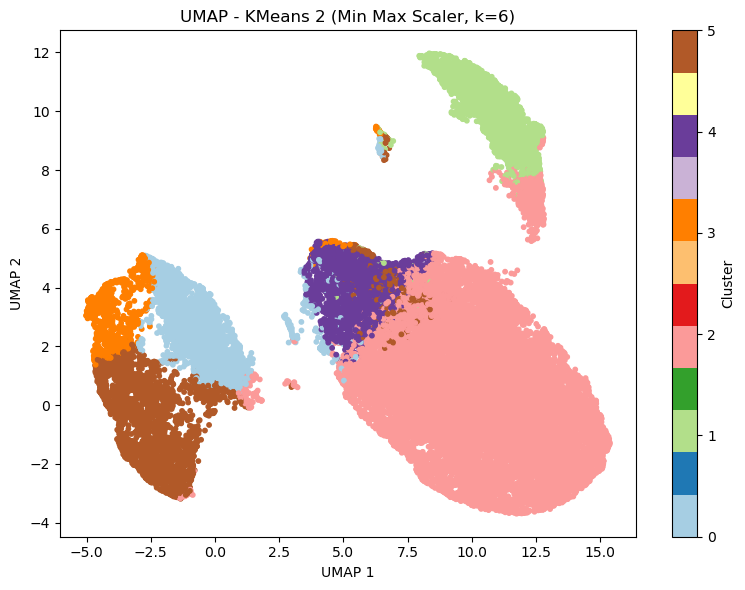

array([[10.139604 , -1.1316028],
       [-1.2433598,  2.283159 ],
       [ 7.6311927,  2.9636812],
       ...,
       [-1.4748552,  2.8296885],
       [10.664835 , -1.0199353],
       [ 4.537698 ,  3.4407077]], shape=(33038, 2), dtype=float32)

In [24]:
# Visualize the KMeans cluster assignments using UMAP dimensionality reduction
plot_umap(clustering_method, labels_kmeans, title="UMAP - KMeans 2 (Min Max Scaler, k=6)")

#### 3D Visualization
This plot shows the cluster structure in a second embedding view for comparison.


In [25]:
# Purpose: Provide a 3D overview of cluster separation in original feature space.
dados_para_plot = clustering_method.copy()
labels_dos_clusters = labels_kmeans

# 1. Run UMAP (3 components) for interactive 3D plotting
umap_3d = umap.UMAP(n_components=3, random_state=42, n_neighbors=15, min_dist=0.1)
components_3d = umap_3d.fit_transform(dados_para_plot)

# 2. Build DataFrame for Plotly
df_3d = pd.DataFrame(components_3d, columns=['UMAP 1', 'UMAP 2', 'UMAP 3'])
df_3d['Cluster'] = labels_dos_clusters.astype(str)

# 3. Interactive 3D scatter: helps validate cluster separation visually
fig = px.scatter_3d(
    df_3d, x='UMAP 1', y='UMAP 2', z='UMAP 3', color='Cluster',
    title="3D Cluster Visualization (UMAP)", opacity=0.7,
    color_discrete_sequence=px.colors.qualitative.Set1
)
fig.update_traces(marker=dict(size=4))
fig.show()


### 2.2 Hierarchical Clustering (2nd Approach)

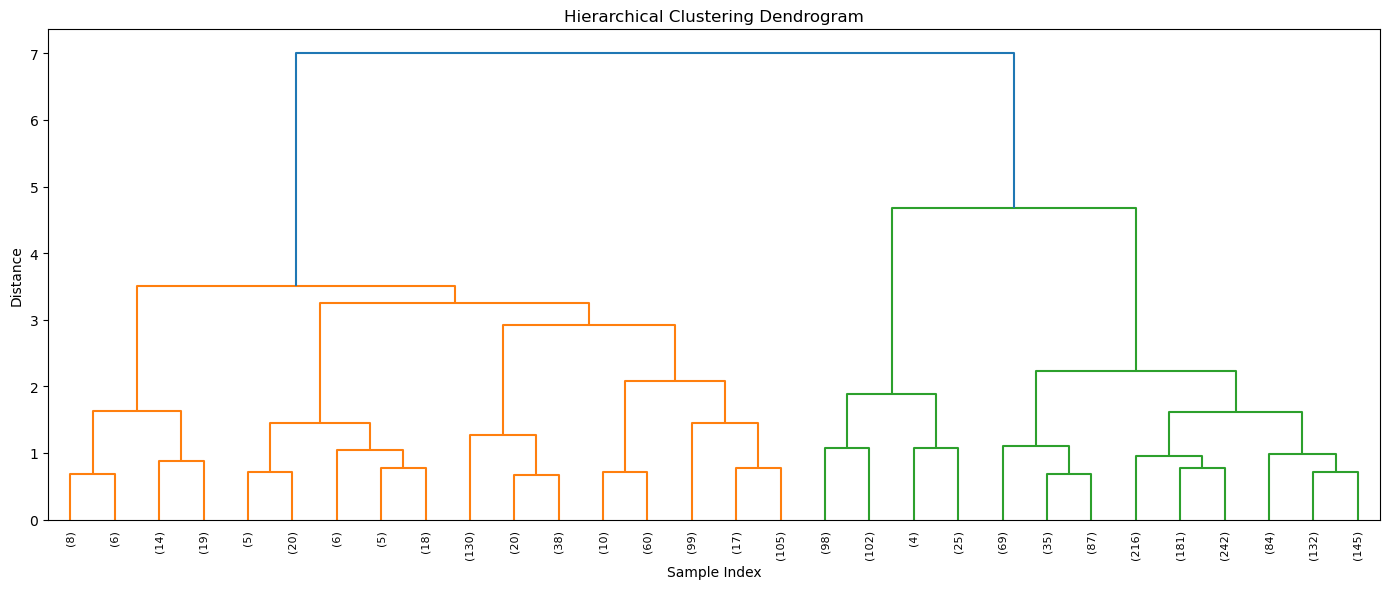

Silhouette Score: 0.3788
Cluster sizes:
0    21008
1     3111
2     3911
3     1467
4      993
5     2548
Name: count, dtype: int64


In [26]:
# Fit the Hierarchical Agglomerative Clustering model with 6 clusters 
hierarchical_model_mm, labels_hierarchical_mm, cluster_profile_hierarchical_mm = fit_hierarchical(clustering_method, 6, method='ward')

In [27]:
display(cluster_profile_hierarchical_mm)

,cluster_0,cluster_1,cluster_2,cluster_3,cluster_4,cluster_5
loyalty_product_type,0.003542,0.002408,0.005606,0.001610,0.003078,0.003788
lifetime_spend_vegetables_prop,0.057589,0.226602,0.038688,0.138652,0.505114,0.265504
lifetime_spend_meat_prop,0.093661,0.022817,0.093685,0.239736,0.015646,0.007598
lifetime_spend_hygiene_prop,0.081470,0.308753,0.045955,0.251615,0.214933,0.098338
lifetime_spend_videogames_prop,0.038889,0.027890,0.264613,0.102046,0.082914,0.040609
lifetime_spend_petfood_prop,0.072117,0.116575,0.065778,0.229426,0.131972,0.065016


#### UMAP Visualization

A 2D UMAP projection illustrating the cluster separation achieved by the Hierarchical Agglomerative model.

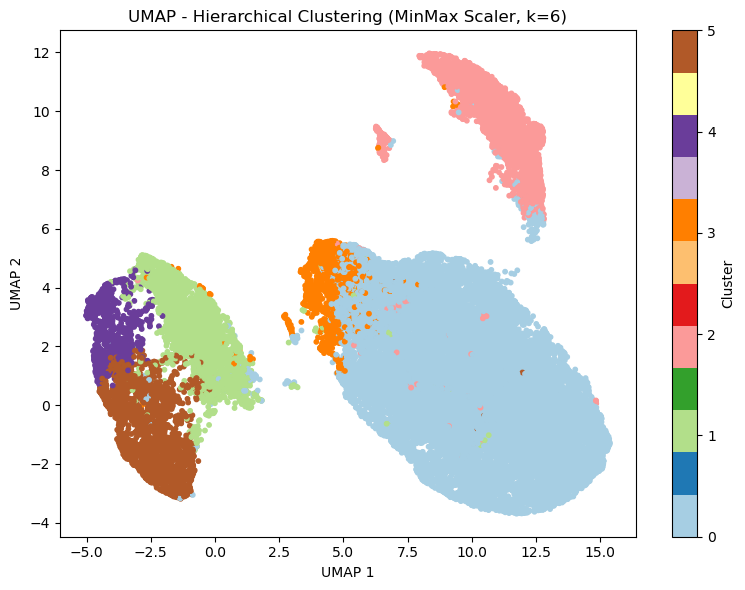

array([[10.139604 , -1.1316028],
       [-1.2433598,  2.283159 ],
       [ 7.6311927,  2.9636812],
       ...,
       [-1.4748552,  2.8296885],
       [10.664835 , -1.0199353],
       [ 4.537698 ,  3.4407077]], shape=(33038, 2), dtype=float32)

In [28]:
plot_umap(clustering_method, labels_hierarchical_mm, title="UMAP - Hierarchical Clustering (MinMax Scaler, k=6)")

### 2.3 Esemble Clustering


In this section, we apply an Ensemble Clustering approach to build a more robust customer segmentation. Instead of relying on a single algorithm's assumptions, we use a "Meta-Learning" strategy.
First, we take the cluster assignments (labels) predicted by our independent base models and use them as new categorical features. Then, we apply a **Meta-Learner** — in our case, a final **K-Means** algorithm—on top of these labels. By clustering the predictions of previous models rather than the raw data, this final model identifies the consensus groupings, combining the strengths of the individual algorithms.

In [29]:
# 1. Base Variables
predictions_kmeans = labels_kmeans
predictions_hierarchical = labels_hierarchical_mm 
df_original_data = clustering_method 

# 2. DataFrame for the Ensemble
df_ensemble = pd.DataFrame({
    'KMeans_Base': predictions_kmeans.astype(str),
    'Hierarchical_Base': predictions_hierarchical.astype(str)
})
df_ensemble_encoded = pd.get_dummies(df_ensemble)

# 3. Final K-Means (Meta-Learner)
k_final = 6
kmeans_ensemble = KMeans(n_clusters=k_final, random_state=42, n_init=10)
labels_ensemble_final = kmeans_ensemble.fit_predict(df_ensemble_encoded)

# 4. Silhouette Score Calculation
sil_score = silhouette_score(df_original_data, labels_ensemble_final)
print(f"The Silhouette Score of the Final Ensemble is: {sil_score:.4f}")


The Silhouette Score of the Final Ensemble is: 0.3926


#### UMAP Visualization

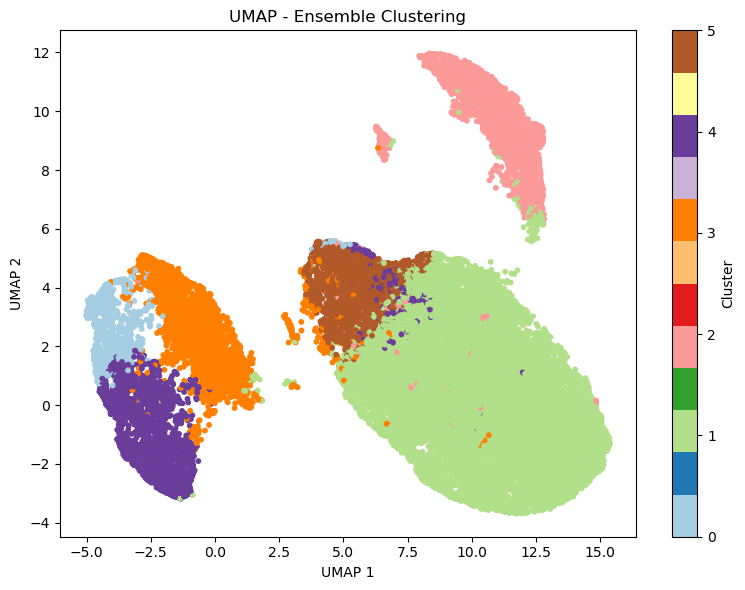

array([[10.139604 , -1.1316028],
       [-1.2433598,  2.283159 ],
       [ 7.6311927,  2.9636812],
       ...,
       [-1.4748552,  2.8296885],
       [10.664835 , -1.0199353],
       [ 4.537698 ,  3.4407077]], shape=(33038, 2), dtype=float32)

In [30]:
plot_umap(df_original_data, labels_ensemble_final, title="UMAP - Ensemble Clustering")



### Ensemble model choice and silhouette comparison
The ensemble model is selected as the best solution because it combines KMeans and hierarchical cluster assignments into a more robust consensus segmentation.
Its silhouette score is lower than some individual models, but it is more stable and better suited for real business interpretation.
This means the ensemble is favored for robustness and reliable customer segment definitions, even if it sacrifices a small amount of silhouette quality.


In [31]:
# Purpose: Create a cluster profile table using original real-valued features.
numeric_variables = clustering_data.select_dtypes(include=['number']).copy()
cluster_profile = numeric_variables.groupby(labels_ensemble_final).mean().T

cluster_profile.columns = [f"Cluster {int(c)}" for c in cluster_profile.columns]

print('Original data cluster profile (real values):')
display(cluster_profile)


Original data cluster profile (real values):


,Cluster 0,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Cluster 5
loyalty_product_type,280.912163,332.266424,527.300960,233.128936,396.232807,206.100789
lifetime_spend_vegetables_prop,0.225661,0.018235,0.014992,0.086786,0.105517,0.049228
lifetime_spend_meat_prop,0.011936,0.034754,0.038736,0.011667,0.009374,0.098127
lifetime_spend_hygiene_prop,0.083761,0.028604,0.017382,0.122296,0.035945,0.069775
lifetime_spend_videogames_prop,0.021865,0.009298,0.070404,0.008006,0.010823,0.022298
lifetime_spend_petfood_prop,0.030184,0.014114,0.014155,0.025327,0.014699,0.041401


The previous table shows average feature values for each ensemble cluster using the original dataset.
This table is the baseline for understanding the practical meaning of each segment.

### Cluster Mapping and Data Export
To finalize our cluster implementation, we map human-readable labels to the clusters based on their behavioral characteristics and export the final dataset, ensuring future insights are actionable for business development and marketing teams.

In [32]:
df['cluster'] = labels_ensemble_final  
df.to_csv('dataset_clusters.csv', index=False)

cluster_mapping = {
    0: "The Plant-Based Consumer",
    1: "The Family Budget Optimizer",
    2: "The Demanding Premium Tech Consumer",
    3: "The Early Morning Hygiene Consumer",
    4: "The Wellness Customer",
    5: "The Affluent Health-Conscious Buyer"
}

df['cluster'] = df['cluster'].map(cluster_mapping)

df.to_csv('dataset_clusters.csv', index='customer_id')

In [33]:
df['cluster']

0                The Family Budget Optimizer
1         The Early Morning Hygiene Consumer
2                The Family Budget Optimizer
3        The Demanding Premium Tech Consumer
4        The Demanding Premium Tech Consumer
                        ...                 
33033    The Demanding Premium Tech Consumer
33034    The Demanding Premium Tech Consumer
33035     The Early Morning Hygiene Consumer
33036     The Early Morning Hygiene Consumer
33037    The Affluent Health-Conscious Buyer
Name: cluster, Length: 33038, dtype: object

## 3. Cluster Profiling & Insights


In [34]:
# Load and prepare data
df_basket_clusters = load_and_prepare_data(
    basket_path='customer_basket.csv',
    clusters_path='dataset_clusters.csv'
)

# 2. Parsear a lista de produtos
df_basket_clusters['list_of_goods_parsed'] = (
    df_basket_clusters['list_of_goods'].apply(convert_string_to_list)
)
# Remove the index 'customer_id' for a future merge with the basket data
df.reset_index().to_csv('dataset_clusters.csv', index=False)

# Plot vizualization
df_basket_clusters.head()

,Unnamed: 0,customer_name,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,...,lifetime_spend_meat_prop,lifetime_spend_fish_prop,lifetime_spend_hygiene_prop,lifetime_spend_videogames_prop,lifetime_spend_petfood_prop,cluster,customer_id,invoice_id,list_of_goods,list_of_goods_parsed
0,0,Bsc. Crystal Kitchens,1.0,3.0,11731.0,4553.0,NaN,373.0,323.0,177.0,...,0.001506,0.011458,0.029693,0.013771,0.020656,The Family Budget Optimizer,3,7994762,"['burgers', 'tomatoes', 'megaman zero 3', 'muf...","[burgers, tomatoes, megaman zero 3, muffins, t..."
1,0,Bsc. Crystal Kitchens,1.0,3.0,11731.0,4553.0,NaN,373.0,323.0,177.0,...,0.001506,0.011458,0.029693,0.013771,0.020656,The Family Budget Optimizer,3,5829775,"['cream', 'portal', 'green tea', 'pepper', 'so...","[cream, portal, green tea, pepper, soda, showe..."
2,1,Bsc. Glenda Bauman,0.0,2.0,13694.0,963.0,NaN,2012.0,533.0,95.0,...,0.002125,0.000741,0.092918,0.016458,0.032867,The Early Morning Hygiene Consumer,4,5564437,"['vegetables mix', 'airpods', 'iphone 10', 'la...","[vegetables mix, airpods, iphone 10, laptop, c..."
3,1,Bsc. Glenda Bauman,0.0,2.0,13694.0,963.0,NaN,2012.0,533.0,95.0,...,0.002125,0.000741,0.092918,0.016458,0.032867,The Early Morning Hygiene Consumer,4,9516601,"['energy drink', 'airpods', 'iphone 10', 'lapt...","[energy drink, airpods, iphone 10, laptop, ext..."
4,2,Msc. Antonio Campbell,NaN,2.0,12407.0,0.0,11.0,555.0,101.0,118.0,...,0.081356,0.017557,0.032607,0.006496,0.014277,The Family Budget Optimizer,5,9251722,"['final fantasy XXII', 'tea', 'brownies', 'pic...","[final fantasy XXII, tea, brownies, pickles, b..."


### 3.1 Core Cluster Profiling

#### Size of the Clusters

In [35]:

pd.Series(labels_ensemble_final).value_counts(ascending=True)


0     1052
5     2648
4     2944
3     3425
2     3922
1    19047
Name: count, dtype: int64

<Axes: title={'center': 'Size of the Clusters'}, ylabel='count'>

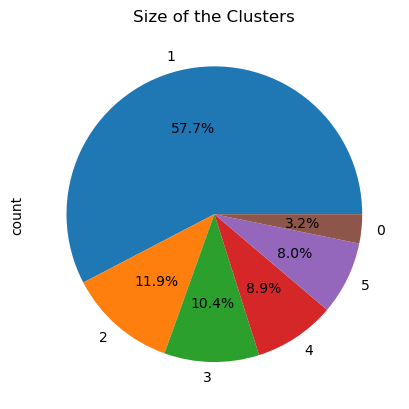

In [36]:

pd.Series(labels_ensemble_final).value_counts().plot.pie(autopct='%1.1f%%', title='Size of the Clusters')


Cluster 1 is the dominant segment with 57.7% of customers (19,047).
Remaining clusters range from 3.2% to 11.9% of the customer base.

#### Radar Charts

The radar charts below provide a multi-dimensional view of each cluster, highlighting the unique spending patterns and dominant product categories for every customer segment.

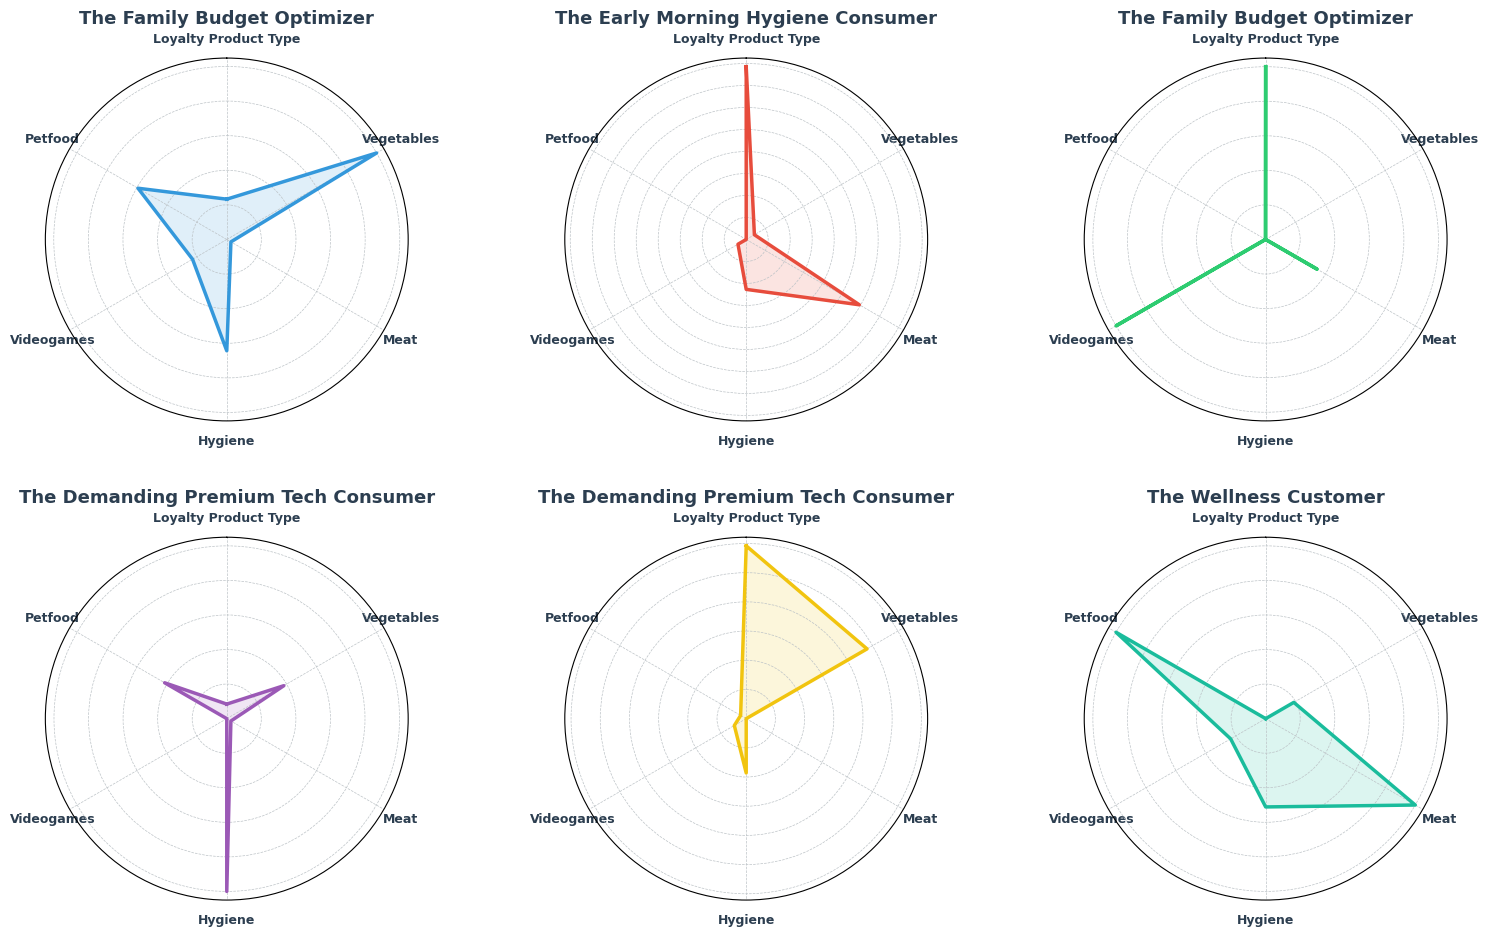

In [37]:

# Purpose: Radar charts compare normalized feature profiles across clusters for multi-dimensional interpretation.
numeric_vars = clustering_method.select_dtypes(include=['number']).copy()
perfil_ensemble = numeric_vars.groupby(labels_ensemble_final).mean()

# ----------------------------------------------------------------------------------
# Why apply MinMaxScaler again here?
# ----------------------------------------------------------------------------------
# The first scaler was applied to individual customers. 
# Here, we scale the cluster averages.
# This forces the highest cluster average to 1.0 and the lowest to 0.0 for each feature, 
# which stretches the radar chart and makes the visual differences between clusters much clearer.
# ----------------------------------------------------------------------------------

# Normalize 0-1 so all variables fit harmoniously on the radar
scaler = MinMaxScaler()
perfil_normalized = pd.DataFrame(
    scaler.fit_transform(perfil_ensemble), 
    columns=perfil_ensemble.columns, 
    index=perfil_ensemble.index
)

# Axis and label cleanup
categories = list(perfil_normalized.columns)
categories_clean = [c.replace('lifetime_spend_', '').replace('_prop', '').replace('_', ' ').title() for c in categories]
num_vars = len(categories)

angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # close the circle

# Create dynamic grid for cluster plots
num_clusters = len(perfil_normalized)
cols = 3
rows = int(np.ceil(num_clusters / cols))

fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows), subplot_kw=dict(polar=True))
axes = axes.flatten()

colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6', '#f1c40f', '#1abc9c']

for idx, cluster_id in enumerate(perfil_normalized.index):
    ax = axes[idx]
    values = perfil_normalized.loc[cluster_id].values.tolist()
    values += values[:1]

    color = colors[idx % len(colors)]
    ax.plot(angles, values, color=color, linewidth=2.5, linestyle='solid')
    ax.fill(angles, values, color=color, alpha=0.15)

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories_clean, color='#2c3e50', size=9, fontweight='bold')

    ax.set_yticklabels([])
    ax.grid(color='#bdc3c7', linestyle='--', linewidth=0.5)

    ax.set_title(f'{df["cluster"].iloc[idx]}', size=13, color='#2c3e50', weight='bold', pad=25)

for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(pad=3.0)
plt.show()


#### Category Purchase Penetration by Cluster
*Out of every 100 customers in this cluster, how many purchased this category at least once?*

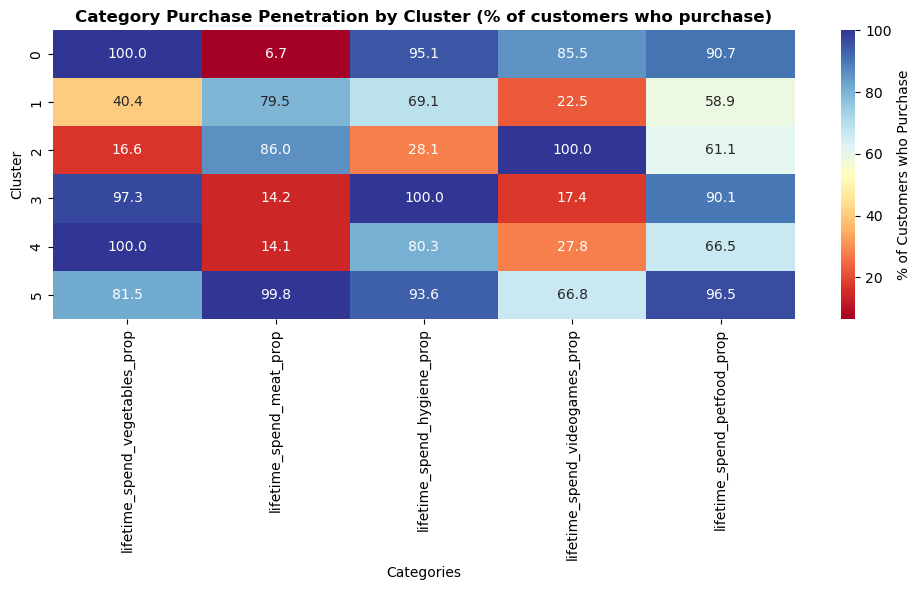

In [38]:
# Purpose: Show the percent of customers in each cluster who purchase each category (penetration).
category_props = [c for c in df_original_data.columns if '_prop' in c]
df_binary = (df_original_data[category_props] > 0.05).astype(int)
df_binary['Cluster'] = labels_ensemble_final

penetration_matrix = df_binary.groupby('Cluster').mean() * 100


plt.figure(figsize=(10, 6))
sns.heatmap(penetration_matrix, annot=True, fmt=".1f", cmap='RdYlBu', cbar_kws={'label': '% of Customers who Purchase'})
plt.title('Category Purchase Penetration by Cluster (% of customers who purchase)', fontsize=12, fontweight='bold')
plt.ylabel('Cluster')
plt.xlabel('Categories')
plt.tight_layout()
plt.show()


#### Key Strategic Takeaways
* **The Wellness-Focused Specialists (Clusters 0, 3, and 4):**
These clusters demonstrate exceptional commitment to health-conscious spending, with near-perfect penetration in both Vegetables (97-100%) and Hygiene products (80-100%). Cluster 3 and 4 show almost complete abstinence from Meat (14% penetration), positioning them as the store's wellness champions.

* **The Meat-Centric Traditionalists (Clusters 1, 2, and 5):**
These segments prioritize protein and traditional food categories. Cluster 2 stands as the outlier—a Videogame specialist with 100% category penetration and minimal interest in vegetables (16.6%), suggesting a younger demographic with niche entertainment focus. Clusters 1 and 5, however, show strong meat purchasing (79-99%) balanced with reasonable vegetable consumption. Cluster 5 emerges as the most valuable: it's a balanced omnivore with high spending across ALL categories (81-99% penetration), making it the ideal target for bundled, cross-category promotions.

* **The Pet Food Halo Effect:**
Clusters 0, 3, 4, and 5 demonstrate exceptional pet food adoption (90-96%), while Clusters 1 and 2 trail significantly (59% and 61%). Pet owners in high-penetration clusters show strong loyalty signals and multi-category engagement, suggesting pet food acts as a trust anchor that drives broader household shopping migration.

* **The Videogame Anomaly (Cluster 2):**
Cluster 2's 100% videogame penetration combined with minimal vegetable interest (16.6%) signals a distinct demographic—likely younger, entertainment-focused customers with different lifestyle priorities. Requires completely separate marketing strategy focused on entertainment bundles rather than household staples.

### 3.2 Extended Demographic & Behavioral Profiling

In [39]:
# 1. Obter os dados reais limpos pela sua função
df_real = cluster_analysis(df.copy())

# 2. Adicionar as labels do seu modelo Ensemble
df_real['Cluster'] = labels_ensemble_final

#### Distributions of all features per cluster

In [40]:
# 3. Filter absolute spending columns
cols_to_remove = [col for col in df_real.columns if 'lifetime_spend' in col and 'prop' not in col]
if 'total_lifetime_spend' in df_real.columns:
    cols_to_remove.append('total_lifetime_spend')

# Add demographic/identifier columns that don't make sense for the mean profile
extra_cols_to_remove = [
    'customer_id', 
    'customer_name', 
    'latitude', 
    'longitude', 'female',
    'has_loyalty_card', 'year_first_transaction'
]
cols_to_remove.extend(extra_cols_to_remove)

# 4. Remove the columns, group by cluster, and calculate the mean
# Using errors='ignore' prevents breaking if the column is already dropped
df_means = df_real.drop(columns=cols_to_remove, errors='ignore').groupby('Cluster').mean(numeric_only = True).T

# Rename columns to "Cluster 0", "Cluster 1", etc.
df_means.columns = [f"Cluster {int(c)}" for c in df_means.columns]

# 5. Display the formatted DataFrame with a row-wise heatmap gradient
# (Using 'RdYlBu' because it's better for gradients than 'Paired')
df_means.style.background_gradient(cmap='RdYlBu', axis=1)



,Cluster 0,Cluster 1,Cluster 2,Cluster 3,Cluster 4,Cluster 5
number_complaints,0.803802,0.995978,1.036461,0.599241,0.794497,0.942674
distinct_stores_visited,3.275285,3.284769,1.832687,3.589723,3.271060,3.592976
typical_hour,13.947148,11.904531,16.673840,10.907212,13.762228,12.656647
lifetime_total_distinct_products,84.454373,176.506274,109.649669,126.896058,87.535326,130.933535
percentage_of_products_bought_promotion,0.130279,0.406589,0.289215,0.184131,0.166022,0.489224
age,57.799049,53.199779,55.505150,56.832526,56.652717,56.800529
total_kids,1.883650,2.361548,0.802652,1.893606,1.893207,1.664804
loyalty_product_type,280.912163,332.266424,527.300960,233.128936,396.232807,206.100789
lifetime_spend_groceries_prop,0.290067,0.553284,0.331377,0.483275,0.508547,0.388399
lifetime_spend_electronics_prop,0.159641,0.074606,0.275574,0.052837,0.097066,0.095065



#### Key Strategic Takeaways

* **Wallet Share vs. Niche Budgets:** 
Traditional groceries dominate the budget for almost everyone (28% to 55%). The big exception is Cluster 3 (Gamers), who disrupt this pattern by burning a massive 27.6% of their entire lifetime budget on Electronics (although they still spend more in groceries).

* **Deal Hunters vs. Premium Shoppers:** 
**Cluster 1** and **Cluster 5** are pure promo hunters, buying 40% and 48% (respectively) of their items on discount across a massive variety of products. On the flip side, Cluster 0 are premium organic shoppers who rarely buy on sale (13% promotion rate), willingly paying full price for vegetables and hygiene.

* **The Family Size Factor:** 
Demographics explain the basket sizes. Cluster 1 represents large families (2.36 kids), driving a massive variety of grocery needs (176 distinct products). Cluster 2 has the fewest kids (0.79), shops late in the afternoon, sticks to very few stores (1.8), and is the most critical segment with the highest complaint rate.

#### Commercial Value: Individual Customer Quality vs. Overall Segment Volume

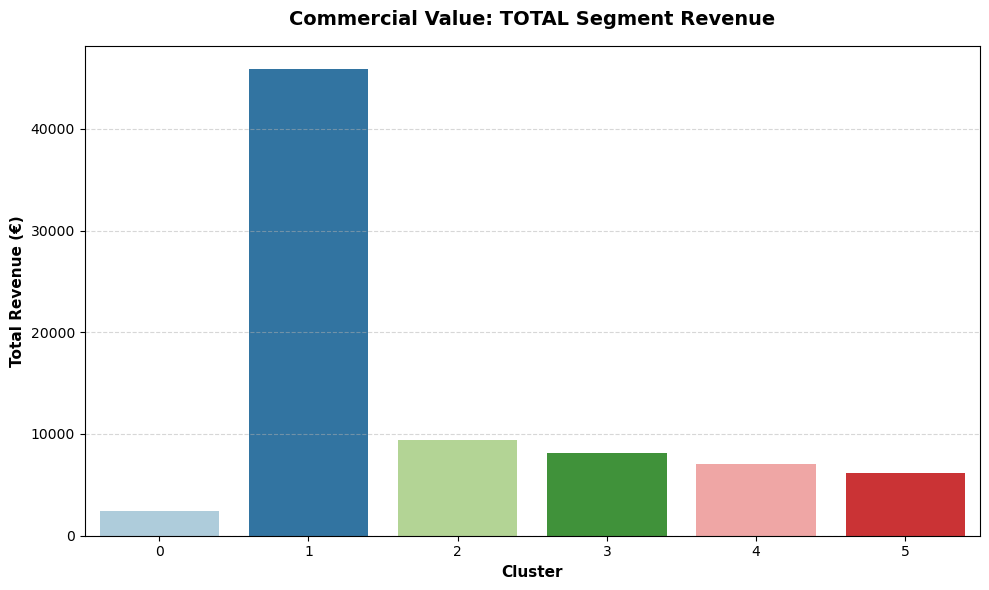

In [41]:
# Calculate the Sum (Total Segment Revenue)
df_sum = df_real.groupby('Cluster')['total_lifetime_spend'].sum().reset_index()

# Create a single plot
plt.figure(figsize=(10, 6))

# THE SUM (Volume/Total Revenue for the Company)
sns.barplot(x='Cluster', y='total_lifetime_spend', data=df_sum, palette='Paired')

# Titles and Labels
plt.title('Commercial Value: TOTAL Segment Revenue', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Total Revenue (€)', fontweight='bold', fontsize=11)
plt.xlabel('Cluster', fontweight='bold', fontsize=11)

# Add a subtle grid to make reading the values easier
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()



#### Key Strategic Takeaways: Value vs. Volume

* **The Revenue Giant (Cluster 1):** Looking at total segment revenue, Cluster 1 is the undisputed powerhouse, generating over €45,000—more than all other clusters combined. However, this financial impact is driven entirely by its sheer volume of customers rather than high individual spend. 

* **The Small Premium Niche (Cluster 5):** Despite purchasing premium wellness items at full price, Cluster 5 generates the lowest total revenue (under €3,000) simply because it represents a very small fraction of the customer base.

* **The Bottom Line:** While niche segments (like Clusters 3 and 5) are excellent targets for specialized, high-margin marketing campaigns, Cluster 1 remains the financial backbone of the business. From a risk perspective, a tiny drop in Cluster 1's retention will hurt the total bottom line far more than losing an entire niche group.


#### Gender Anaylsis per Cluster

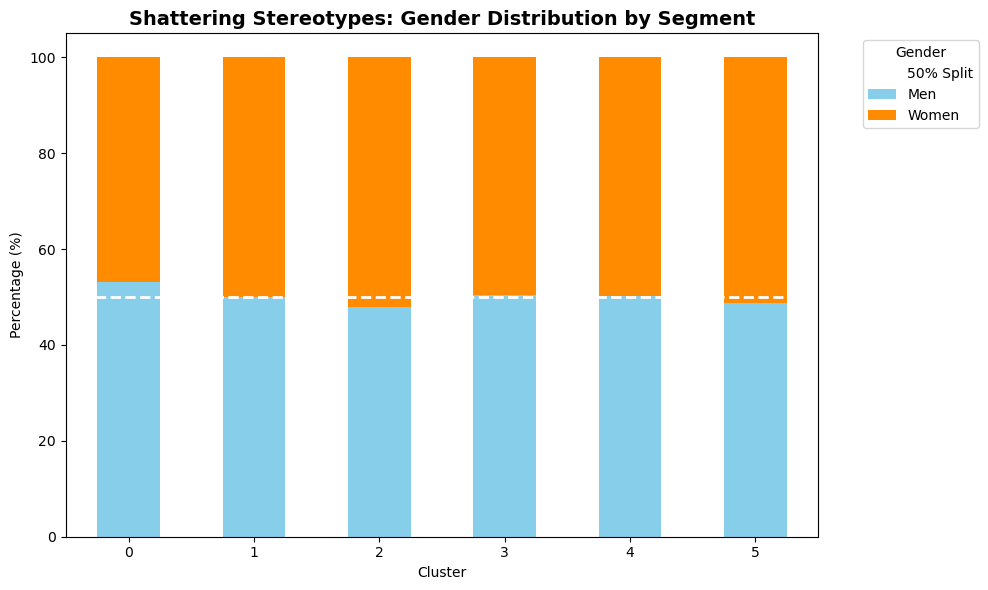

In [42]:
df_gender = df_real.groupby('Cluster')['female'].value_counts(normalize=True).unstack()
df_gender.columns = ['Men', 'Women']
df_gender = df_gender * 100 # Convert to percentage

# Draw the 100% stacked bar chart
ax = df_gender.plot(
    kind='bar', 
    stacked=True, 
    figsize=(10, 6), 
    color=['#87CEEB', '#FF8C00'] )

plt.title('Shattering Stereotypes: Gender Distribution by Segment', fontsize=14, fontweight='bold')
plt.ylabel('Percentage (%)')
plt.xlabel('Cluster')

# Draw a line exactly at 50% to visually prove the point!
plt.axhline(50, color='white', linestyle='--', linewidth=2, label='50% Split')

# Move the legend outside the plot area
plt.legend(title='Gender', bbox_to_anchor=(1.05, 1), loc='upper left')

# Keep X labels horizontal
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



Gender is entirely irrelevant for targeting these segments: Every cluster has a nearly perfect 50/50 split, proving that shopping behavior and product loyalty are completely independent of gender.

#### Loyalty Card Anaylsis per Cluster

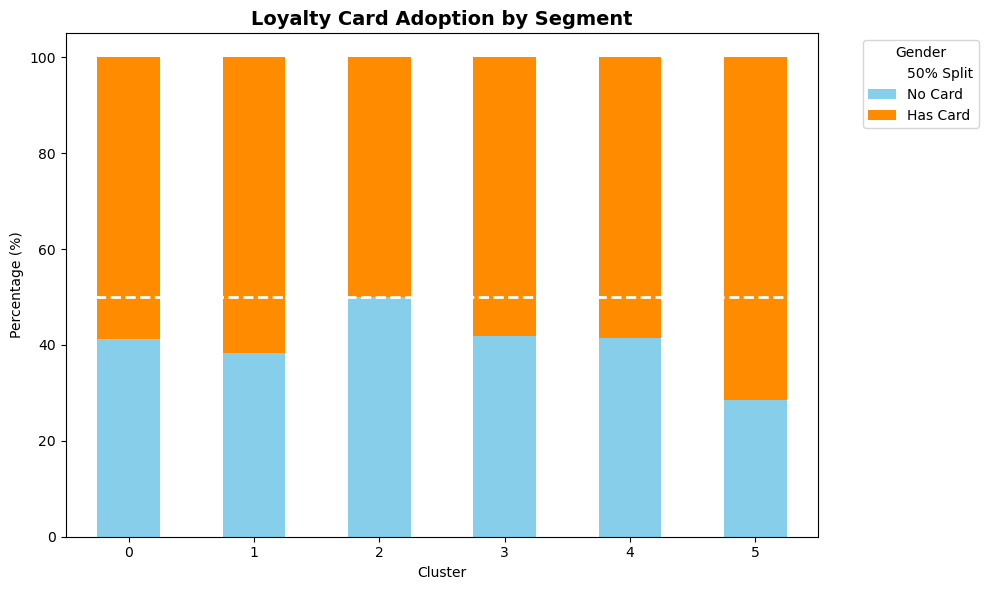

In [43]:
df_loyalty = df_real.groupby('Cluster')['has_loyalty_card'].value_counts(normalize=True).unstack()
df_loyalty.columns = ['No Card', 'Has Card']
df_loyalty = df_loyalty * 100 # Convert to percentage

# Draw the 100% stacked bar chart
ax = df_loyalty.plot(
    kind='bar', 
    stacked=True, 
    figsize=(10, 6), 
    color=['#87CEEB', '#FF8C00'] 
)

plt.title('Loyalty Card Adoption by Segment', fontsize=14, fontweight='bold')
plt.ylabel('Percentage (%)')
plt.xlabel('Cluster')

# Draw a line exactly at 50% to visually prove the point!
plt.axhline(50, color='white', linestyle='--', linewidth=2, label='50% Split')

# Move the legend outside the plot area
plt.legend(title='Gender', bbox_to_anchor=(1.05, 1), loc='upper left')

# Keep X labels horizontal
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### Key Strategic Takeaways: Loyalty Card Adoption

* **The Bottom Line:** Your loyalty program is highly attractive to traditional families but fails to connect with tech/entertainment buyers; the rewards system needs to be gamified or adapted to digital products to capture Cluster 2.

#### Boxplots


These plots use original customer features from the dataset, including age, distinct stores visited, promotion purchase share, and complaints.
The stacked bar charts show loyalty card adoption and gender distribution by cluster, which are important for translating cluster segments into marketing and retention actions.

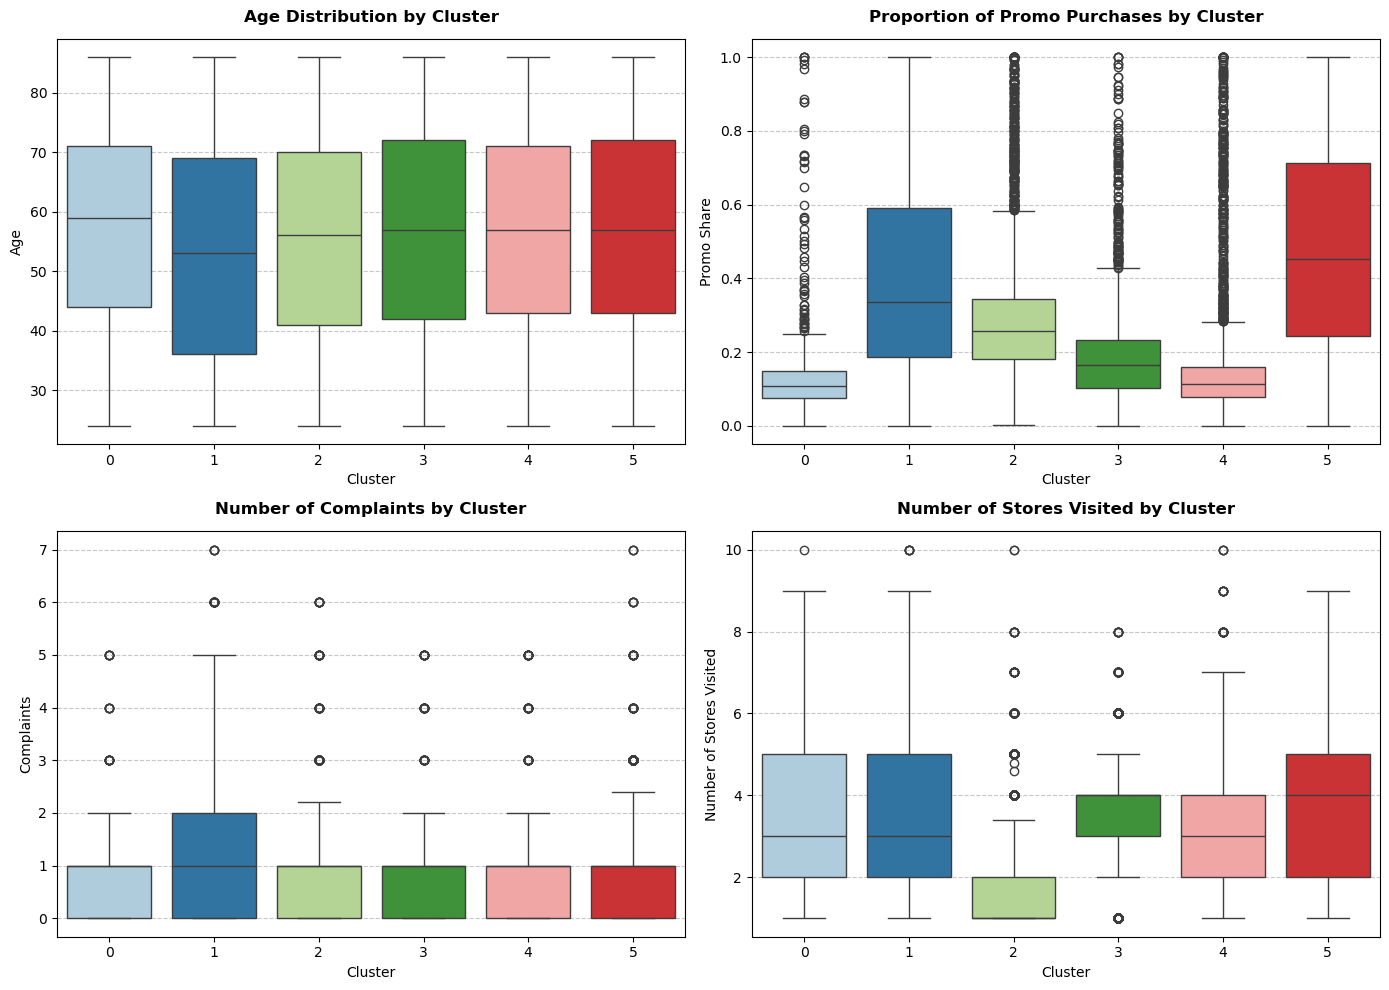

In [44]:
vars_num = ['age', 'percentage_of_products_bought_promotion', 'number_complaints', 'distinct_stores_visited']
titles_num = ['Age Distribution by Cluster','Proportion of Promo Purchases by Cluster', 'Number of Complaints by Cluster', 'Number of Stores Visited by Cluster']
ylabels = ['Age', 'Promo Share', 'Complaints', 'Number of Stores Visited']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, var in enumerate(vars_num):
    sns.boxplot(data=df_real, x='Cluster', y=var, ax=axes[idx], palette='Paired', hue='Cluster', legend=False)
    axes[idx].set_title(titles_num[idx], fontweight='bold', pad=12)
    axes[idx].set_xlabel('Cluster')
    axes[idx].set_ylabel(ylabels[idx])
    axes[idx].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()



#### Geographic Anaylsis

In [45]:
from shapely.geometry import Point
import geopandas as gpd
# Purpose: Map ensemble clusters geographically to check whether segments correlate with location.
df_mapa = df_real.copy()
df_mapa['Cluster'] = labels_ensemble_final

geometry = [Point(xy) for xy in zip(df_mapa.longitude, df_mapa.latitude)]
customer_info_gd = gpd.GeoDataFrame(df_mapa, geometry=geometry, crs='EPSG:4326')

print('Generating the cluster geography map...')
cluster_map = customer_info_gd.iloc[0:1000].explore(
    column='Cluster',
    categorical=True,
    cmap='Set1',
    legend=True,
    marker_kwds=dict(radius=5, fill=True),
    tooltip=['customer_name', 'Cluster', 'total_lifetime_spend']
)

cluster_map

Generating the cluster geography map...


### 4.Cluster Names & Profiles

#### Cluster 0: The Plant-Based Consumer

* **Core profile:** Households centered on vegetables and hygiene.
* **Key Behaviours:** This cluster shows a high consumption of vegetables and hygiene products. Although they project a very health-conscious lifestyle, they are actually the cluster that consumes the most alcohol.


#### Cluster 1: The Family Budget Optimizer

* **Core profile:**  Large families managing tight budgets with high volume requirements.Households centered on fresh produce and daily essentials.
* **Key Behaviours:** High reliance on promotional campaigns to manage substantial household expenses. They exhibit the highest volume of distinct products purchased, reflecting the complexity of family logistics.



#### Cluster 2: The Demanding Premium Tech Consumer 

* **Core profile:** Independent, tech-focused, and convenience-seeking consumers.
* **Key Behaviours:** Purchasing is statistically independent from standard household goods. They show little interest in staples like hygiene or fresh produce, focusing instead on electronics and entertainment.



#### Cluster 3: The Early Morning Hygiene Consumer

* **Core profile:** Convenience-focused pet owners who prioritize home/personal hygiene and prefer shopping during early-morning hours.
* **Key Behaviours:** go to more disctint stores and are the most satisfied costumer and not promotion seekers



#### Cluster 4: The Wellness Customer

* **Core profile:** Health-conscious individuals deeply dedicated to personal care, wellness, and self-care routines.
* **Key Behaviours:** They view and trust the brand primarily as a specialized provider of health, hygiene, and wellness solutions, maintaining consistent shopping habits centered around these categories.



#### Cluster 5: The Affluent Health-Conscious Buyer

* **Core profile:** Premium, health-conscious consumers with pets, who heavily balance a high-end lifestyle with strategic budget management.
* **Key Behaviours:** They are active "promotion hunters" who visit the highest number of distinct store locations, frequently shifting between retailers to secure deals on high-ticket fresh items like premium meat and fish.


## 4. Association Rules (Market Basket Analysis)
This section applies the Apriori algorithm to discover purchasing patterns, both globally and segmented by customer cluster.


### 4.1. Load & Prepare Data


In [46]:
df_basket_clusters = load_and_prepare_data(
    basket_path='customer_basket.csv',
    clusters_path='dataset_clusters.csv'
)

df_basket_clusters['list_of_goods_parsed'] = (
    df_basket_clusters['list_of_goods'].apply(convert_string_to_list)
)

print(f"Total records loaded: {len(df_basket_clusters)}")
df_basket_clusters.head()

Total records loaded: 100000


,index,customer_name,number_complaints,distinct_stores_visited,lifetime_spend_groceries,lifetime_spend_electronics,typical_hour,lifetime_spend_vegetables,lifetime_spend_nonalcohol_drinks,lifetime_spend_alcohol_drinks,...,lifetime_spend_meat_prop,lifetime_spend_fish_prop,lifetime_spend_hygiene_prop,lifetime_spend_videogames_prop,lifetime_spend_petfood_prop,cluster,customer_id,invoice_id,list_of_goods,list_of_goods_parsed
0,0,Bsc. Crystal Kitchens,1.0,3.0,11731.0,4553.0,NaN,373.0,323.0,177.0,...,0.001506,0.011458,0.029693,0.013771,0.020656,The Family Budget Optimizer,3,7994762,"['burgers', 'tomatoes', 'megaman zero 3', 'muf...","[burgers, tomatoes, megaman zero 3, muffins, t..."
1,0,Bsc. Crystal Kitchens,1.0,3.0,11731.0,4553.0,NaN,373.0,323.0,177.0,...,0.001506,0.011458,0.029693,0.013771,0.020656,The Family Budget Optimizer,3,5829775,"['cream', 'portal', 'green tea', 'pepper', 'so...","[cream, portal, green tea, pepper, soda, showe..."
2,1,Bsc. Glenda Bauman,0.0,2.0,13694.0,963.0,NaN,2012.0,533.0,95.0,...,0.002125,0.000741,0.092918,0.016458,0.032867,The Early Morning Hygiene Consumer,4,5564437,"['vegetables mix', 'airpods', 'iphone 10', 'la...","[vegetables mix, airpods, iphone 10, laptop, c..."
3,1,Bsc. Glenda Bauman,0.0,2.0,13694.0,963.0,NaN,2012.0,533.0,95.0,...,0.002125,0.000741,0.092918,0.016458,0.032867,The Early Morning Hygiene Consumer,4,9516601,"['energy drink', 'airpods', 'iphone 10', 'lapt...","[energy drink, airpods, iphone 10, laptop, ext..."
4,2,Msc. Antonio Campbell,NaN,2.0,12407.0,0.0,11.0,555.0,101.0,118.0,...,0.081356,0.017557,0.032607,0.006496,0.014277,The Family Budget Optimizer,5,9251722,"['final fantasy XXII', 'tea', 'brownies', 'pic...","[final fantasy XXII, tea, brownies, pickles, b..."


### 4.2. Global Association Rules (All Customers)


In [47]:
all_baskets = df_basket_clusters['list_of_goods_parsed'].tolist()

# Top products chart
plot_top_products(all_baskets, "Global Dataset")

# Run Apriori
items_all, rules_all = run_association_rules(
    all_baskets, min_support=0.02, min_confidence=0.15, split_train=True
)

print(f"Frequent Itemsets found: {len(items_all)}")
print(f"Rules generated: {len(rules_all)}")

Frequent Itemsets found: 171
Rules generated: 14


In [48]:
print("→ Top 10 Frequent Itemsets:")
display(clean_items_df(items_all.head(10)))

print("\n→ Top 15 Rules (sorted by Lift):")
if not rules_all.empty:
    display(clean_rules_df(
        rules_all[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(15)
    ))
    print(calculate_metric_range(rules_all, 'lift'))
    plot_association_results(rules_all, "Global Dataset")
else:
    print("No rules generated for the current thresholds.")

→ Top 10 Frequent Itemsets:


,support,itemsets
0,0.1203,[airpods]
1,0.0632,[almonds]
2,0.0698,[antioxydant juice]
3,0.1274,[asparagus]
4,0.0664,[avocado]
5,0.0844,[babies food]
6,0.0688,[bacon]
7,0.0510,[barbecue sauce]
8,0.0558,[beer]
9,0.0452,[black beer]



→ Top 15 Rules (sorted by Lift):


,antecedents,consequents,support,confidence,lift
0,[airpods],[energy drink],0.0248,0.2058,2.8029
1,[energy drink],[airpods],0.0248,0.3372,2.8029
2,[airpods],[bluetooth headphones],0.0241,0.2000,2.7887
3,[bluetooth headphones],[airpods],0.0241,0.3355,2.7887
4,[eggs],[cereals],0.0224,0.2408,2.3772
5,[cereals],[eggs],0.0224,0.2213,2.3772
6,[butter],[eggs],0.0206,0.2136,2.2941
7,[eggs],[butter],0.0206,0.2216,2.2941
8,[cereals],[fresh bread],0.0228,0.2246,2.2568
9,[fresh bread],[cereals],0.0228,0.2286,2.2568


lift Range: 0.7120 (Min: 2.0909, Max: 2.8029)


### 4.3. Association Rules by Customer Cluster

Each cluster is analysed independently using the same support and confidence thresholds.

In [49]:
DEFAULT_SUPPORT    = 0.02
DEFAULT_CONFIDENCE = 0.15

for cluster_id, cluster_name in CLUSTER_NAMES_MAP.items():
    print("\n" + "="*70)
    print(f"CLUSTER {cluster_id}: {cluster_name}")
    print("="*70)

    df_sub = df_basket_clusters[df_basket_clusters['cluster'] == cluster_name]
    cluster_baskets = df_sub['list_of_goods_parsed'].tolist()
    print(f"Transactions: {len(cluster_baskets)}")

    if not cluster_baskets:
        print("⚠️  No records found for this cluster.")
        continue

    # Top products
    plot_top_products(cluster_baskets, cluster_name)

    # Apriori
    items_cl, rules_cl = run_association_rules(
        cluster_baskets,
        min_support=DEFAULT_SUPPORT,
        min_confidence=DEFAULT_CONFIDENCE,
        split_train=True
    )

    # Frequent itemsets
    print(f"\n→ Frequent Itemsets (Top 10 of {len(items_cl)}):")
    if not items_cl.empty:
        display(clean_items_df(items_cl.head(10)))
    else:
        print(f"   No itemsets above {DEFAULT_SUPPORT*100}% support.")

    # Rules
    print(f"\n→ Association Rules (Top 10 of {len(rules_cl)}):")
    if not rules_cl.empty:
        display(clean_rules_df(
            rules_cl[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10)
        ))
        print(calculate_metric_range(rules_cl, 'lift'))
        plot_association_results(rules_cl, cluster_name)
    else:
        print(f"   No rules generated (Support={DEFAULT_SUPPORT*100}%, Confidence={DEFAULT_CONFIDENCE*100}%).")
        print("   Suggests independent purchasing behaviour within this segment.")


CLUSTER 0: The Plant-Based Consumer
Transactions: 3803

→ Frequent Itemsets (Top 10 of 308):


,support,itemsets
0,0.0569,[airpods]
1,0.0450,[almonds]
2,0.0503,[antioxydant juice]
3,0.0891,[asparagus]
4,0.0398,[avocado]
5,0.2837,[babies food]
6,0.0398,[bacon]
7,0.0437,[barbecue sauce]
8,0.0487,[beer]
9,0.0408,[black beer]



→ Association Rules (Top 10 of 234):


,antecedents,consequents,support,confidence,lift
0,"[dog food, napkins]",[milk],0.0230,0.2555,1.5574
1,"[babies food, napkins]",[milk],0.0237,0.2517,1.5347
2,"[babies food, milk]",[napkins],0.0237,0.4138,1.5332
3,"[babies food, napkins]",[cooking oil],0.0385,0.4091,1.5269
4,"[fresh bread, dog food]",[napkins],0.0214,0.4088,1.5147
5,"[toilet paper, napkins]",[dog food],0.0233,0.4176,1.4982
6,"[cereals, napkins]",[babies food],0.0230,0.4242,1.4954
7,"[dog food, napkins]",[toilet paper],0.0233,0.2591,1.4901
8,"[babies food, napkins]",[cereals],0.0230,0.2448,1.4861
9,"[dog food, napkins]",[fresh bread],0.0214,0.2372,1.4849


lift Range: 0.6172 (Min: 0.9402, Max: 1.5574)

CLUSTER 1: The Family Budget Optimizer
Transactions: 51769

→ Frequent Itemsets (Top 10 of 188):


...

lift Range: 0.6285 (Min: 1.0017, Max: 1.6303)

CLUSTER 5: The Affluent Health-Conscious Buyer
Transactions: 6905

→ Frequent Itemsets (Top 10 of 173):


,support,itemsets
0,0.1703,[airpods]
1,0.0576,[almonds]
2,0.0411,[antioxydant juice]
3,0.1157,[asparagus]
4,0.0507,[avocado]
5,0.0550,[babies food]
6,0.0567,[bacon]
7,0.0583,[barbecue sauce]
8,0.0773,[beer]
9,0.0516,[black beer]



→ Association Rules (Top 10 of 13):


,antecedents,consequents,support,confidence,lift
0,[energy drink],[bluetooth headphones],0.0219,0.2459,2.6638
1,[bluetooth headphones],[energy drink],0.0219,0.2373,2.6638
2,[airpods],[bluetooth headphones],0.0387,0.2274,2.4632
3,[bluetooth headphones],[airpods],0.0387,0.4196,2.4632
4,[airpods],[energy drink],0.0360,0.2115,2.3744
5,[energy drink],[airpods],0.0360,0.4045,2.3744
6,[pancakes],[airpods],0.0228,0.3281,1.9262
7,[laptop],[airpods],0.0275,0.3077,1.8063
8,[airpods],[laptop],0.0275,0.1615,1.8063
9,[energy bar],[airpods],0.0237,0.3005,1.7638


lift Range: 1.0473 (Min: 1.6165, Max: 2.6638)


## 5. Final Conclusions & Business Recommendations

### Summary of Results

| Cluster | Name | Transactions | Rules Found | Max Lift |
|---------|------|-------------|-------------|----------|
| 0 | The Plant-Based Household | 4,020 | 160 | 1.82 |
| 1 | The Family Budget Optimizer | 51,879 | 45 | 2.78 |
| 2 | The Promotion-Driven Pet Parent | 10,100 | 1,064 | 3.67 |
| 3 | The Demanding Premium Tech Consumer | 14,882 | 0 | N/A |
| 4 | The Wellness Customer | 12,214 | 158 | 1.67 |
| 5 | The Affluent Health-Conscious Buyer | 6,905 | 13 | 2.66 |




Global sales are driven by high-volume airpods, almounds and antioxydant juices. Marketing strategies must tailor to specific clusters: 

The Family Budget Optimizer (Cluster 1): Dominates total volume, fueled by high-volume essentials like asparagus (16% support) and entry-level tech bundles.

The Plant-Based Household and The Wellness Customer (Clusters 0 & 4): Anchored by babies food as a massive traffic driver (~24% support). Highly predictable routines link babies food ↔ dog food ↔ cooking oil ↔ napkins (lifts up to 1.81).

The Promotion-Driven Pet Parent (Cluster 2): Prime target for promotions, yielding 1,064 rules. Features the strongest purchasing signal in the dataset: bluetooth headphones → airpods (max lift 3.67).

The Demanding Premium Tech Consumer (Cluster 3): Generated zero association rules across 14.8k transactions. Purchasing is statistically independent; skip bundles and focus purely on premium upselling.

The Affluent Health-Conscious Buyer (Cluster 5): Highest individual demand for airpods (17% support). Strong tech-lifestyle pairings link bluetooth headphones ↔ energy drink (2.66 lift).